In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dhoogla_cicids2017_path = kagglehub.dataset_download('dhoogla/cicids2017')

print('Data source import complete.')


Data source import complete.


In [2]:
# ───────────────────────────────────────────────────────────────────────────────
# DYNAMIC ENVIRONMENT SETUP FOR MULTIPLE GPU/TPU CONFIGURATIONS
# ───────────────────────────────────────────────────────────────────────────────

import os, random, warnings

# 1) GPU/TPU CONFIGURATION
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info messages
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import pandas as pd
import numpy as np

# Improved hardware detection
try:
    # First try TPU detection
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    device_type = 'TPU'
    print(f"✅ Using TPU: {tpu.master()}")
except (ValueError, tf.errors.NotFoundError):
    # If TPU not found, check for GPUs
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Use all available GPUs
        strategy = tf.distribute.MirroredStrategy()
        device_type = 'GPU'
        print(f"✅ Using {len(gpus)} GPU(s)")
    else:
        # Fallback to CPU
        strategy = tf.distribute.get_strategy()
        device_type = 'CPU'
        print("✅ Using CPU")

print("Visible devices:", tf.config.get_visible_devices())

# 2) PRECISION CONFIGURATION
from tensorflow.keras import mixed_precision

if device_type == 'TPU':
    policy = mixed_precision.Policy('mixed_bfloat16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_bfloat16 (required for TPU)")
elif any('gpu' in d.device_type.lower() for d in tf.config.get_visible_devices()):
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_float16")
else:
    print("✅ Precision: float32 (CPU mode)")

# 3) GPU MEMORY MANAGEMENT (skip for TPU)
if device_type == 'GPU':
    for gpu in tf.config.list_physical_devices('GPU'):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

    
# 4) PERFORMANCE OPTIMIZATIONS
# Enable XLA compilation
tf.config.optimizer.set_jit(True)

# Configure dataset pipeline
options = tf.data.Options()
options.experimental_optimization.parallel_batch = True
options.threading.private_threadpool_size = min(8, os.cpu_count() or 8)

# 5) REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── PYDATA & ML LIBRARIES ─────────────────────────────────────────────────────

from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import VarianceThreshold, SelectFromModel
from sklearn.ensemble             import RandomForestClassifier
from sklearn.preprocessing        import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition        import PCA
from sklearn.utils                import resample, class_weight
from sklearn.metrics              import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.manifold             import TSNE

# Optional UMAP embedding
try:
    from umap import UMAP
    print("✅ UMAP imported")
except ImportError:
    print("⚠️ UMAP not available")

# ─── DEEP LEARNING UTILITIES ───────────────────────────────────────────────────
from tensorflow.keras             import layers, models, optimizers, callbacks
from tensorflow.data              import Dataset
from tensorflow.python.framework  import convert_to_constants

# ─── IMAGE / AUTOENCODER METRICS ───────────────────────────────────────────────
# Correct installation and import of scikit-image
try:
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image metrics imported")
except ImportError:
    print("Installing scikit-image for image metrics...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image installed and imported")

# ─── PLOTTING ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f"✅ Environment configured | TensorFlow {tf.__version__} | Device: {device_type}")

2026-03-22 17:03:18.735553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774198998.990573      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774198999.063085      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Using CPU
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✅ Precision: float32 (CPU mode)


2026-03-22 17:03:37.187108: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ UMAP imported
✅ scikit-image metrics imported
✅ Environment configured | TensorFlow 2.18.0 | Device: CPU


# **Modules and Libs**

# **Data Loading**

In [3]:
benign_dir = "/kaggle/input/datasets/dhoogla/cicids2017/Benign-Monday-no-metadata.parquet"
botnet_dir = "/kaggle/input/datasets/dhoogla/cicids2017/Botnet-Friday-no-metadata.parquet"
brute_dir = "/kaggle/input/datasets/dhoogla/cicids2017/Bruteforce-Tuesday-no-metadata.parquet"
ddos_dir = "/kaggle/input/datasets/dhoogla/cicids2017/DDoS-Friday-no-metadata.parquet"
dos_dir = "/kaggle/input/datasets/dhoogla/cicids2017/DoS-Wednesday-no-metadata.parquet"
infiltr_dir = "/kaggle/input/datasets/dhoogla/cicids2017/Infiltration-Thursday-no-metadata.parquet"
portscan_dir = "/kaggle/input/datasets/dhoogla/cicids2017/Portscan-Friday-no-metadata.parquet"
webatk_dir = "/kaggle/input/datasets/dhoogla/cicids2017/WebAttacks-Thursday-no-metadata.parquet"

In [4]:
benign   = pd.read_parquet(benign_dir,   engine="pyarrow")
botnet   = pd.read_parquet(botnet_dir,   engine="pyarrow")
brute    = pd.read_parquet(brute_dir,    engine="pyarrow")
ddos     = pd.read_parquet(ddos_dir,     engine="pyarrow")
dos      = pd.read_parquet(dos_dir,      engine="pyarrow")
infiltr  = pd.read_parquet(infiltr_dir,  engine="pyarrow")
portscan = pd.read_parquet(portscan_dir, engine="pyarrow")
webatk   = pd.read_parquet(webatk_dir,   engine="pyarrow")

In [5]:
benign

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458826,6,18738,1,1,6,6,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
458827,17,60797,2,2,80,156,40,40,40.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
458828,17,154,2,2,64,96,32,32,32.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
458829,17,155,2,2,80,144,40,40,40.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [6]:
DFs = {
    "benign":   benign,
    "botnet":   botnet,
    "brute":    brute,
    "ddos":     ddos,
    "dos":      dos,
    "infiltr":  infiltr,
    "portscan": portscan,
    "webatk":   webatk
}

In [7]:
names = list(DFs.keys())
rows  = [DFs[n].shape[0] for n in names]

In [8]:
# Overview & Structure
for name, df in DFs.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} cols")
    print(df.dtypes, "\n")

benign: 458831 rows × 78 cols
Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int32
Total Backward Packets         int32
Fwd Packets Length Total       int32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                       int32
Idle Min                       int32
Label                       category
Length: 78, dtype: object 

botnet: 176038 rows × 78 cols
Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int32
Total Backward Packets         int32
Fwd Packets Length Total       int32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                       int32
Idle Min                       int32
Label                       category
Length: 78, dtype: object 

brute: 389714 rows × 78 cols
Protocol                        int8
Flow

# **Data Analysis**

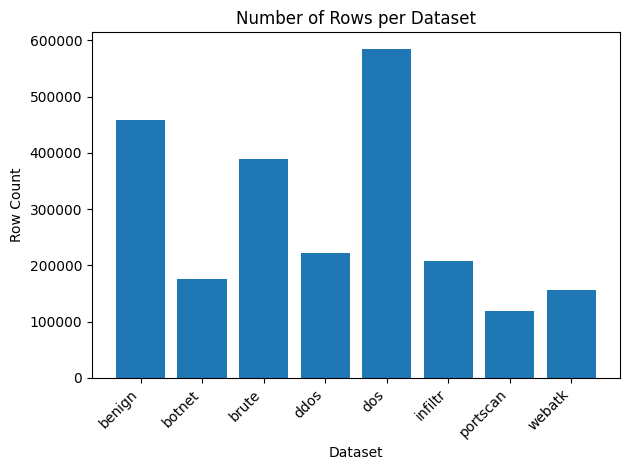

In [9]:
plt.figure()
plt.bar(names, rows)
plt.title("Number of Rows per Dataset")
plt.xlabel("Dataset")
plt.ylabel("Row Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Missing Values
for name, df in DFs.items():
    print(f"{name}:")
    print("Total & per‐column missingness: \n")
    print(f"{df.isna().sum().sort_values(ascending=False)}")
    print("Percent missing: \n")
    print(f"{(df.isna().mean() * 100).round(2)}", "\n")

benign:
Total & per‐column missingness: 

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min             0
Fwd IAT Max             0
Fwd IAT Std             0
Label                   0
Length: 78, dtype: int64
Percent missing: 

Protocol                    0.0
Flow Duration               0.0
Total Fwd Packets           0.0
Total Backward Packets      0.0
Fwd Packets Length Total    0.0
                           ... 
Idle Mean                   0.0
Idle Std                    0.0
Idle Max                    0.0
Idle Min                    0.0
Label                       0.0
Length: 78, dtype: float64 

botnet:
Total & per‐column missingness: 

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min            

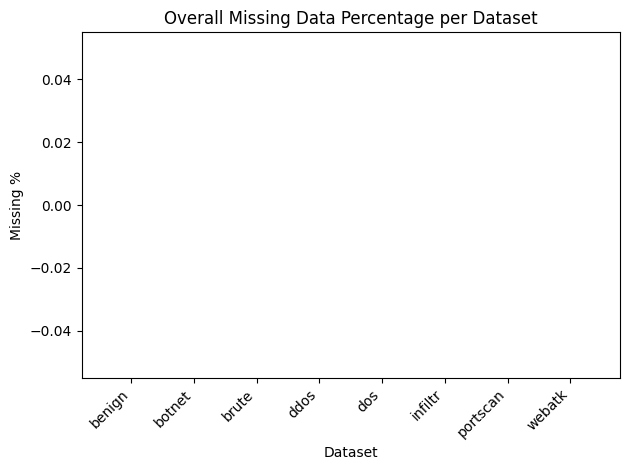

In [11]:
miss_pct = [
    DFs[n].isna().sum().sum() / (DFs[n].size) * 100
    for n in names
]

plt.figure()
plt.bar(names, miss_pct)
plt.title("Overall Missing Data Percentage per Dataset")
plt.xlabel("Dataset")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Basic Statistics
for name, df in DFs.items():
    print(f"{name}:")
    print("Numerical summary: \n")
    print(f"{df.describe().T}")
    print("Categorical counts: \n")
    for col in df.select_dtypes(include=["object", "category"]).columns:
        print(col, df[col].value_counts())

benign:
Numerical summary: 

                             count          mean           std  min    25%  \
Protocol                  458831.0  1.103306e+01  5.486413e+00  0.0    6.0   
Flow Duration             458831.0  1.196980e+07  3.056838e+07 -1.0  281.0   
Total Fwd Packets         458831.0  1.171436e+01  9.590487e+02  1.0    2.0   
Total Backward Packets    458831.0  1.319606e+01  1.260931e+03  0.0    1.0   
Fwd Packets Length Total  458831.0  6.082904e+02  6.690243e+03  0.0   43.0   
...                            ...           ...           ...  ...    ...   
Active Min                458831.0  5.059022e+04  5.363391e+05  0.0    0.0   
Idle Mean                 458831.0  3.999468e+06  1.389472e+07  0.0    0.0   
Idle Std                  458831.0  2.338050e+05  2.321827e+06  0.0    0.0   
Idle Max                  458831.0  4.180491e+06  1.432384e+07  0.0    0.0   
Idle Min                  458831.0  3.780202e+06  1.361037e+07  0.0    0.0   

                              50% 

In [13]:
# Class Balance
combined = pd.concat([df.assign(source=name) for name, df in DFs.items()], ignore_index=True)
combined["Label"].value_counts(normalize=True) * 100

Label
Benign                        85.457233
DoS Hulk                       7.470190
DDoS                           5.532606
DoS GoldenEye                  0.444548
FTP-Patator                    0.256330
DoS slowloris                  0.232733
DoS Slowhttptest               0.225948
SSH-Patator                    0.139121
PortScan                       0.084536
Web Attack � Brute Force       0.063532
Bot                            0.062105
Web Attack � XSS               0.028179
Infiltration                   0.001556
Web Attack � Sql Injection     0.000908
Heartbleed                     0.000475
Name: proportion, dtype: float64

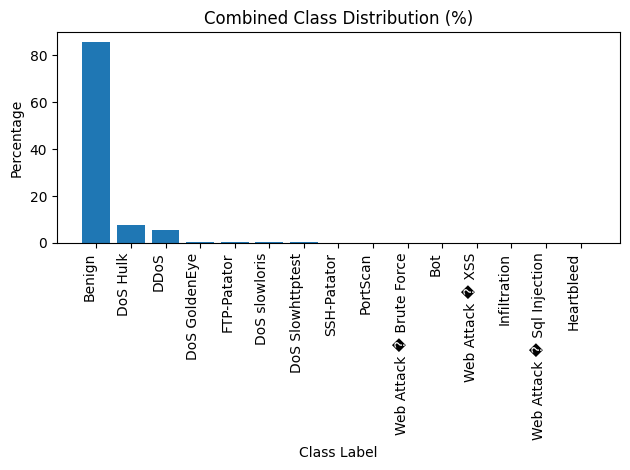

In [14]:
class_dist = combined["Label"].value_counts(normalize=True) * 100

plt.figure()
plt.bar(class_dist.index.astype(str), class_dist.values)
plt.title("Combined Class Distribution (%)")
plt.xlabel("Class Label")
plt.ylabel("Percentage")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# inspect columns for one of your DFs
print(DFs["benign"].columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

# **Data Integration & Cleaning**

**Type costintency**

In [16]:
def enforce_numeric(df):
    # Define substrings that identify numeric fields
    patterns = ["Count", "Packet", "Bytes", "Length", "Duration", "Rate", "Mean", "Std", "Max", "Min"]

    for col in df.columns:
        # If the column name matches any of our numeric patterns...
        if any(pat in col for pat in patterns):
            # Try converting to numeric, coerce any bad entries to NaN
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# Apply to each dataset
for name, df in DFs.items():
    DFs[name] = enforce_numeric(df)

Even if they already look numeric, it’s good practice to explicitly cast by name‑pattern.

**Encode the protocol type**

In [17]:
combined = pd.concat([df.assign(source=name) for name, df in DFs.items()], ignore_index=True)

In [18]:
# Keep original protocol values
combined["Protocol"] = combined["Protocol"].astype("Int64")

# One-hot encode directly from original protocol values
combined = pd.get_dummies(combined, columns=["Protocol"], prefix="proto", dtype=np.int8)

For deep‐learning models like LSTMs, CNNs or GRUs, you generally want to avoid feeding raw ordinal integers wherever possible—because the network will assume a spurious numerical ordering (e.g. Protocol 17 > Protocol 6) that doesn’t actually carry semantic meaning

**Add Rate/Ratio Columns**

In [19]:
# Handle negative/zero values BEFORE transforms
eps = 1e-3

essential_cols = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Fwd Packets Length Total",
    "Bwd Packets Length Total",
    "Flow Bytes/s",
    "Flow Packets/s"
]

# Replace inf with NaN first
combined[essential_cols] = combined[essential_cols].replace([np.inf, -np.inf], np.nan)

# Mark impossible values as NaN
combined.loc[combined["Flow Duration"] <= 0, "Flow Duration"] = np.nan
combined.loc[combined["Total Fwd Packets"] < 0, "Total Fwd Packets"] = np.nan
combined.loc[combined["Total Backward Packets"] < 0, "Total Backward Packets"] = np.nan

# Drop rows with invalid essential fields
combined = combined.dropna(subset=["Flow Duration", "Total Fwd Packets", "Total Backward Packets"])

In [20]:
eps = 1e-6

combined["Total Packets"] = combined["Total Fwd Packets"] + combined["Total Backward Packets"]
combined["Total Bytes"] = combined["Fwd Packets Length Total"] + combined["Bwd Packets Length Total"]

combined["Packet_Rate"] = combined["Total Packets"] / (combined["Flow Duration"] / 1e6 + eps)
combined["Bytes_per_Packet"] = combined["Total Bytes"] / (combined["Total Packets"] + eps)

combined["Idle_CV"] = combined["Idle Std"] / (combined["Idle Mean"].replace(0, np.nan) + eps)
combined["Active_CV"] = combined["Active Std"] / (combined["Active Mean"].replace(0, np.nan) + eps)

combined["Idle_CV"] = combined["Idle_CV"].fillna(0)
combined["Active_CV"] = combined["Active_CV"].fillna(0)

In [21]:
# We need to use the protocol dummy columns created earlier
protocol_cols = [col for col in combined.columns if col.startswith('proto_')]



# Create burst ratio feature safely
if 'Fwd Packets/s' in combined.columns and 'Flow Packets/s' in combined.columns:
    combined['Burst_Ratio'] = combined['Fwd Packets/s'] / (combined['Flow Packets/s'] + 1e-5)
else:
    # Fallback if required columns are missing
    combined['Burst_Ratio'] = 0

In [22]:
import os
import pandas as pd
import numpy as np
from scipy.stats import entropy

cache_path = "/kaggle/working/packet_entropy.csv"

if os.path.exists(cache_path):
    print("Loading cached Packet_Entropy...")
    combined['Packet_Entropy'] = pd.read_csv(cache_path)['Packet_Entropy']
else:
    print("Computing Packet_Entropy...")

    # Add epsilon to avoid log(0)
    fwd = combined['Fwd Packet Length Std'].values + 1e-9
    bwd = combined['Bwd Packet Length Std'].values + 1e-9

    # Stack into 2D array (vectorized)
    probs = np.vstack((fwd, bwd)).T

    # Normalize to probabilities (required for entropy)
    probs = probs / probs.sum(axis=1, keepdims=True)

    # Compute entropy vectorized
    packet_entropy = entropy(probs.T, base=2)

    combined['Packet_Entropy'] = packet_entropy

    # Save to cache
    pd.DataFrame({'Packet_Entropy': packet_entropy}).to_csv(cache_path, index=False)
    print("Saved to cache.")

Computing Packet_Entropy...
Saved to cache.


**Time-Based Feature Extraction**

In [23]:
if 'Timestamp' in combined.columns:
    # Convert to datetime
    combined['Timestamp'] = pd.to_datetime(combined['Timestamp'])

    # Extract temporal features
    combined['Hour'] = combined['Timestamp'].dt.hour
    combined['DayOfWeek'] = combined['Timestamp'].dt.dayofweek
    combined['Is_Weekend'] = combined['DayOfWeek'].isin([5,6]).astype(int)

    # Peak hour flag (9AM-5PM)
    combined['Peak_Hour'] = combined['Hour'].between(9, 17).astype(int)

**Post-Feature Engineering Validation**

In [24]:
# Check new features
print("New Features Summary:")
print(combined.describe())

New Features Summary:
       Flow Duration  Total Fwd Packets  Total Backward Packets  \
count   2.313722e+06       2.313722e+06            2.313722e+06   
mean    1.807644e+07       1.108430e+01            1.255378e+01   
std     3.640876e+07       8.292036e+02            1.103200e+03   
min     1.000000e+00       1.000000e+00            0.000000e+00   
25%     4.760000e+02       2.000000e+00            1.000000e+00   
50%     6.480200e+04       2.000000e+00            2.000000e+00   
75%     5.857224e+06       6.000000e+00            5.000000e+00   
max     1.200000e+08       2.197590e+05            2.919220e+05   

       Fwd Packets Length Total  Bwd Packets Length Total  \
count              2.313722e+06              2.313722e+06   
mean               6.664297e+02              1.977051e+04   
std                1.105030e+04              2.503189e+06   
min                0.000000e+00              0.000000e+00   
25%                3.700000e+01              2.600000e+01   
50%     

# **Feature Selection & Dimensionality Reduction**

In [25]:
combined = combined.drop(columns=["source"])  

y = combined["Label"]
X = combined.drop(columns=["Label"])

# keep only numeric columns
X = X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("NaN count after cleaning:", combined.isna().sum().sum())
print("Inf count after cleaning:", np.isinf(combined.select_dtypes(include=np.number)).sum().sum())

NaN count after cleaning: 0
Inf count after cleaning: 0


**Remove Low-Variance Features**

In [27]:
variance_selector = VarianceThreshold(threshold=0.001)
X_train_high_var = variance_selector.fit_transform(X_train)
retained_features = X_train.columns[variance_selector.get_support()]

corr_matrix = pd.DataFrame(X_train_high_var, columns=retained_features).corr().abs()
high_corr = np.where(np.triu(corr_matrix > 0.9, k=1))

to_drop = set()
for row, col in zip(*high_corr):
    to_drop.add(retained_features[col])

selected_features = [f for f in retained_features if f not in to_drop]

X_train_final = pd.DataFrame(X_train_high_var, columns=retained_features)[selected_features]
X_test_final = pd.DataFrame(
    variance_selector.transform(X_test),
    columns=retained_features
)[selected_features]

In [28]:
X_train_final = pd.DataFrame(X_train_high_var, columns=retained_features)[selected_features]
X_test_final = variance_selector.transform(X_test)
X_test_final = pd.DataFrame(X_test_final, columns=retained_features)[selected_features]

print(f"Final feature count: {len(selected_features)}")
print(f"Train shape: {X_train_final.shape}, Test shape: {X_test_final.shape}")

Final feature count: 40
Train shape: (1850977, 40), Test shape: (462745, 40)


**Embedded Methods (Feature Importance)**

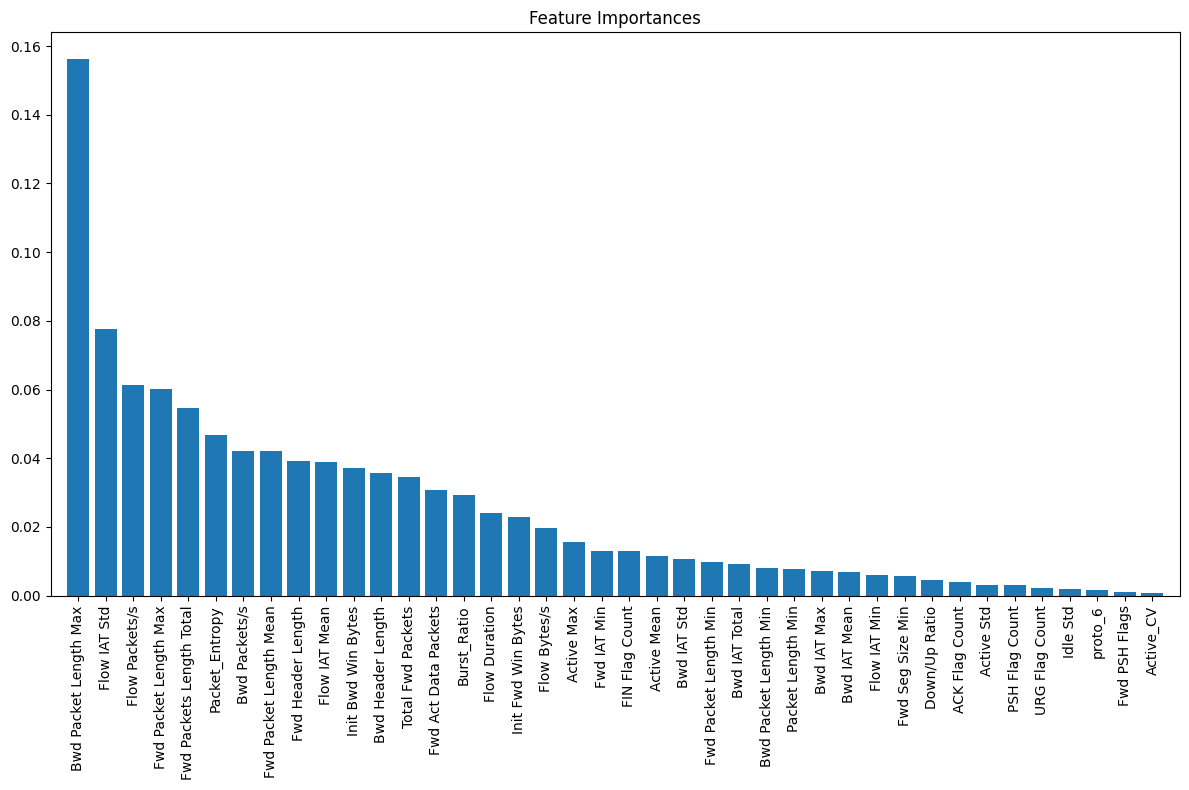

Selected 34 most important features from 40


In [29]:
# Train Random Forest on selected features
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)

# Get feature importances
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.title("Feature Importances")
plt.bar(range(X_train_final.shape[1]), importances[sorted_idx], align='center')
plt.xticks(range(X_train_final.shape[1]), np.array(selected_features)[sorted_idx], rotation=90)
plt.xlim([-1, X_train_final.shape[1]])
plt.tight_layout()
plt.show()

# Select top 85% of features (drop bottom 15%)
keep_percentage = 0.85
n_keep = int(len(selected_features) * keep_percentage)
important_features = np.array(selected_features)[sorted_idx][:n_keep]

print(f"Selected {n_keep} most important features from {len(selected_features)}")

# Filter datasets
X_train_important = X_train_final[important_features]
X_test_important = X_test_final[important_features]

**Dimensionality Reduction (PCA)**

In [30]:
# Apply PCA only if needed (rule of thumb: >50 features)
if len(important_features) > 50:
    # Determine optimal components to retain 95% variance
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_important)

    print(f"Reduced to {pca.n_components_} components (95% variance retained)")
    print(f"Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.4f}")

    # Apply to test set
    X_test_pca = pca.transform(X_test_important)

    # Optional: Convert to DataFrame for readability
    X_train_final = pd.DataFrame(X_train_pca,
                                columns=[f"PC_{i+1}" for i in range(pca.n_components_)])
    X_test_final = pd.DataFrame(X_test_pca,
                               columns=[f"PC_{i+1}" for i in range(pca.n_components_)])
else:
    print("Skipping PCA - feature count acceptable")
    X_train_final = X_train_important
    X_test_final = X_test_important

# Final dataset shapes
print("\nFinal feature dimensions:")
print(f"Train: {X_train_final.shape}, Test: {X_test_final.shape}")

Skipping PCA - feature count acceptable

Final feature dimensions:
Train: (1850977, 34), Test: (462745, 34)


# **Train/Test Splitting**

**Group Rare Attack Classes**

In [31]:
# Calculate class frequencies using TRAINING SET ONLY to prevent data leakage
train_class_dist = y_train.value_counts(normalize=True) * 100
print("Training Set Class Distribution:")
print(train_class_dist)

# Define rare class threshold (0.1%)
rare_threshold = 0.1
rare_classes = train_class_dist[train_class_dist < rare_threshold].index.tolist()

print(f"\nRare classes (<{rare_threshold}%): {rare_classes}")

# Adjust training labels
y_train_adjusted = y_train.replace(rare_classes, "Other")

# Adjust test labels:
# 1. Replace classes identified as rare in training set
# 2. Replace any unseen classes in test set
train_classes = set(y_train.unique())
test_classes = set(y_test.unique())
unseen_classes = list(test_classes - train_classes)

y_test_adjusted = y_test.replace(rare_classes + unseen_classes, "Other")

# Verify new distribution
print("\nAdjusted Training Class Distribution:")
print(y_train_adjusted.value_counts(normalize=True) * 100)

print("\nAdjusted Test Class Distribution:")
print(y_test_adjusted.value_counts(normalize=True) * 100)

Training Set Class Distribution:
Label
Benign                        85.456653
DoS Hulk                       7.470487
DDoS                           5.532808
DoS GoldenEye                  0.444576
FTP-Patator                    0.256351
DoS slowloris                  0.232742
DoS Slowhttptest               0.225935
SSH-Patator                    0.139116
PortScan                       0.084550
Web Attack � Brute Force       0.063534
Bot                            0.062075
Web Attack � XSS               0.028201
Infiltration                   0.001567
Web Attack � Sql Injection     0.000918
Heartbleed                     0.000486
Name: proportion, dtype: float64

Rare classes (<0.1%): ['PortScan', 'Web Attack � Brute Force', 'Bot', 'Web Attack � XSS', 'Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']

Adjusted Training Class Distribution:
Label
Benign              85.456653
DoS Hulk             7.470487
DDoS                 5.532808
DoS GoldenEye        0.444576
FTP-Patator 

In [32]:
# Use the FINAL feature sets from previous steps
print("Final feature dimensions:")
print(f"Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# These are the features we'll use for modeling
print("\nFirst 5 features:")
print(X_train_final.columns[:5].tolist())

Final feature dimensions:
Train: (1850977, 34), Test: (462745, 34)

First 5 features:
['Bwd Packet Length Max', 'Flow IAT Std', 'Flow Packets/s', 'Fwd Packet Length Max', 'Fwd Packets Length Total']


**Train/Test Sets for Modeling**

In [33]:
# Our final datasets for modeling
X_train_model = X_train_final
X_test_model = X_test_final
y_train_model = y_train_adjusted
y_test_model = y_test_adjusted

# Save original test labels for rare class analysis
y_test_original = y_test

In [34]:
from collections import Counter

print("\nClass distribution verification:")
print("Training set:")
print(Counter(y_train_model))

print("\nTest set:")
print(Counter(y_test_model))

# Check stratification quality
train_props = y_train_model.value_counts(normalize=True)
test_props = y_test_model.value_counts(normalize=True)

print("\nClass Proportion Comparison:")
prop_diff = (train_props - test_props).abs()
print(prop_diff)
assert prop_diff.max() < 0.01, "Class proportions differ significantly"


Class distribution verification:
Training set:
Counter({'Benign': 1581783, 'DoS Hulk': 138277, 'DDoS': 102411, 'DoS GoldenEye': 8229, 'FTP-Patator': 4745, 'Other': 4467, 'DoS slowloris': 4308, 'DoS Slowhttptest': 4182, 'SSH-Patator': 2575})

Test set:
Counter({'Benign': 395447, 'DoS Hulk': 34569, 'DDoS': 25603, 'DoS GoldenEye': 2057, 'FTP-Patator': 1186, 'Other': 1116, 'DoS slowloris': 1077, 'DoS Slowhttptest': 1046, 'SSH-Patator': 644})

Class Proportion Comparison:
Label
Benign              1.316222e-06
DoS Hulk            6.613332e-07
DDoS                4.505806e-07
DoS GoldenEye       5.474599e-07
FTP-Patator         5.444092e-07
Other               1.624674e-06
DoS slowloris       3.772196e-09
DoS Slowhttptest    1.076847e-06
SSH-Patator         5.379996e-07
Name: proportion, dtype: float64


# **Class Balancing**

**Analyze Class Distribution**

Training Class Counts:
Label
Benign              1581783
DoS Hulk             138277
DDoS                 102411
DoS GoldenEye          8229
FTP-Patator            4745
Other                  4467
DoS slowloris          4308
DoS Slowhttptest       4182
SSH-Patator            2575
Name: count, dtype: int64


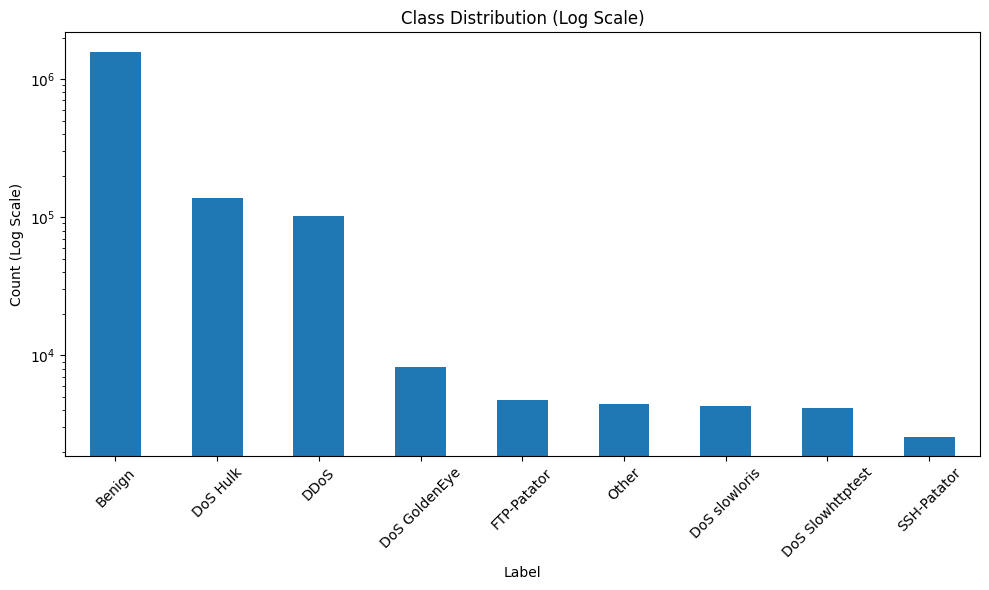

In [35]:
class_counts = y_train_model.value_counts()
print("Training Class Counts:")
print(class_counts)

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', logy=True)
plt.title("Class Distribution (Log Scale)")
plt.ylabel("Count (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hybrid balancing**

Class counts before resampling:
Label
Benign              1581783
DoS Hulk             138277
DDoS                 102411
DoS GoldenEye          8229
FTP-Patator            4745
Other                  4467
DoS slowloris          4308
DoS Slowhttptest       4182
SSH-Patator            2575
Name: count, dtype: int64
Processing class: Benign, samples: 1581783
  Multiplier: 0.5, Target samples: 790891
Processing class: Other, samples: 4467
  Multiplier: 15.0, Target samples: 67005
Processing class: FTP-Patator, samples: 4745
  Multiplier: 1.0, Target samples: 4745
Processing class: SSH-Patator, samples: 2575
  Multiplier: 1.0, Target samples: 2575
Processing class: DDoS, samples: 102411
  Multiplier: 2.0, Target samples: 204822
Processing class: DoS slowloris, samples: 4308
  Multiplier: 1.0, Target samples: 4308
Processing class: DoS Slowhttptest, samples: 4182
  Multiplier: 1.0, Target samples: 4182
Processing class: DoS Hulk, samples: 138277
  Multiplier: 2.0, Target samples: 276554
Pro

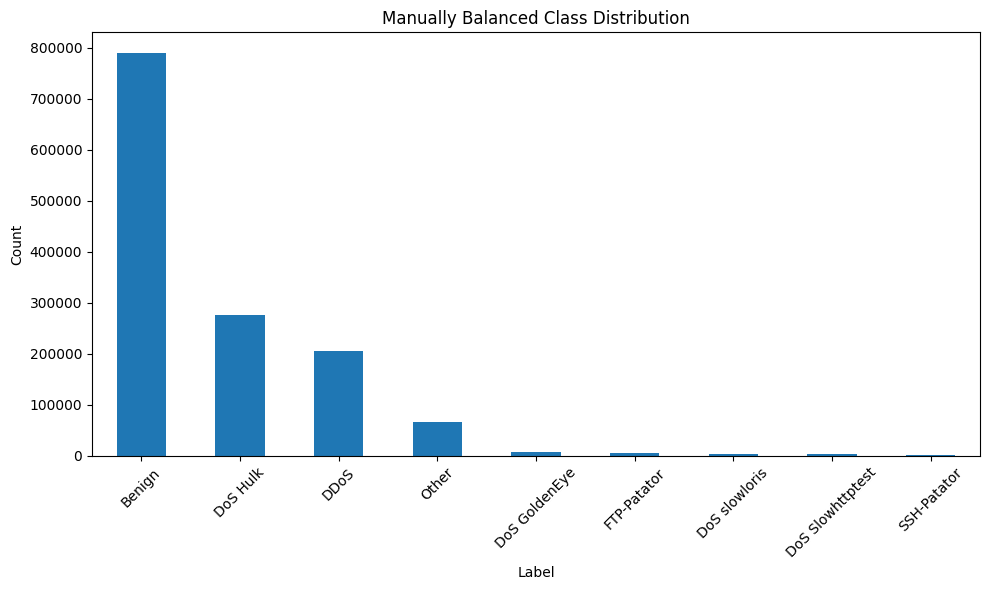

In [36]:
# Convert to DataFrame for easier manipulation
X_train_df = pd.DataFrame(X_train_model, columns=X_train_model.columns)
y_train_series = pd.Series(y_train_model, name='Label')
train_data = pd.concat([X_train_df, y_train_series], axis=1)
train_data = train_data.dropna(subset=['Label'])

# Resampling configuration
resample_config = {
    'Benign': 0.5,      # Downsample to 50%
    'DoS Hulk': 2.0,     # Upsample to 200%
    'DDoS': 2.0,         # Upsample to 200%
    'Other': 15.0,       # Upsample to 1500%
    # Others remain at 100%
}

# Debug: Print class counts before resampling
print("Class counts before resampling:")
print(train_data['Label'].value_counts())

# Apply hybrid resampling with protection
resampled_dfs = []
for cls in train_data['Label'].unique():
    cls_data = train_data[train_data['Label'] == cls]
    print(f"Processing class: {cls}, samples: {len(cls_data)}")

    if len(cls_data) == 0:
        print(f"Warning: Class {cls} has 0 samples. Skipping.")
        continue

    multiplier = resample_config.get(cls, 1.0)
    n_samples = max(1, int(len(cls_data) * multiplier))
    print(f"  Multiplier: {multiplier}, Target samples: {n_samples}")

    # Skip resampling if n_samples would be 0
    if n_samples < 1:
        print(f"Warning: Invalid n_samples={n_samples} for class {cls}. Using original samples.")
        resampled = cls_data
    else:
        try:
            resampled = resample(
                cls_data,
                replace=n_samples > len(cls_data),
                n_samples=n_samples,
                random_state=42
            )
        except ValueError as e:
            print(f"Error resampling class {cls}: {e}")
            print("Using original samples as fallback")
            resampled = cls_data

    resampled_dfs.append(resampled)

# Combine resampled data
balanced_data = pd.concat(resampled_dfs, ignore_index=True)
X_train_bal = balanced_data.drop('Label', axis=1)
y_train_bal = balanced_data['Label']

# Verify new distribution
print("\nBalanced Class Distribution:")
print(y_train_bal.value_counts())

# Visualize new distribution
plt.figure(figsize=(10, 6))
y_train_bal.value_counts().plot(kind='bar')
plt.title("Manually Balanced Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train_bal) 

classes = np.unique(y_train_model)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_model)
class_weights = dict(zip(classes, weights))

# Map to label encoder indices for Keras
index_class_weights = { label_encoder.transform([c])[0]: class_weights[c] for c in classes }

print("\nSecurity-Optimized Class Weights:")
for cls, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls}: {weight:.4f}")


Security-Optimized Class Weights:
SSH-Patator: 79.8696
DoS Slowhttptest: 49.1784
DoS slowloris: 47.7400
Other: 46.0408
FTP-Patator: 43.3433
DoS GoldenEye: 24.9926
DDoS: 2.0082
DoS Hulk: 1.4873
Benign: 0.1300


# **Scaling & Normalization**

In [38]:
X_train_bal_values = X_train_bal.to_numpy()
X_test_final_values = X_test_final.to_numpy()

var_cols = np.nanvar(X_train_bal_values, axis=0)
const_idx = np.where(var_cols == 0)[0]

if len(const_idx):
    print("dropping constant features:", X_train_bal.columns[const_idx].tolist())
    X_train_bal_values = np.delete(X_train_bal_values, const_idx, axis=1)
    X_test_final_values = np.delete(X_test_final_values, const_idx, axis=1)

In [39]:
for col in X_train_model.columns:
    if 'Active' in col or 'IAT' in col or 'Flow' in col:
        p99 = np.percentile(X_train_model[col], 99.9)
        p01 = np.percentile(X_train_model[col], 0.1)
        X_train_model[col] = np.clip(X_train_model[col], p01, p99)
        X_test_model[col] = np.clip(X_test_model[col], p01, p99)

eps = 1e-8
heavy_tail_cols = ['Active Mean', 'Active Max', 'Idle Max', 'Flow Duration']
for df in [X_train, X_test]:
    for col in heavy_tail_cols:
        df[col] = df[col].clip(lower=eps)
        df[col] = np.log1p(df[col])

# Use BALANCED features for scaling
X_train_bal_values = X_train_bal.values
X_test_final_values = X_test_final.values

# Fit scaler on original training set (X_train_final from your orig split)
scaler = QuantileTransformer(n_quantiles=min(1000, X_train_final.shape[0]),
                             output_distribution='normal',
                             random_state=42)
scaler.fit(X_train_final.values)   # fit on original (non-resampled) train
X_train_scaled = scaler.transform(X_train_bal.values)  # balanced (resampled) train
X_test_scaled  = scaler.transform(X_test_final.values)

print("Balanced dataset dimensions:")
print(f"Train features: {X_train_scaled.shape}, Train labels: {y_train_bal.shape}")
print(f"Test features: {X_test_scaled.shape}, Test labels: {y_test_model.shape}")

# Verify scaling
print("\nScaled Feature Summary (Training Set):")
print(pd.DataFrame(X_train_scaled).describe().loc[['mean', 'std', 'min', 'max']].T)

/tmp/ipykernel_13/2147462570.py:12: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].clip(lower=eps)
/tmp/ipykernel_13/2147462570.py:12: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].clip(lower=eps)
/tmp/ipykernel_13/2147462570.py:12: FutureWarning: Downcasting b

Balanced dataset dimensions:
Train features: (1363311, 34), Train labels: (1363311,)
Test features: (462745, 34), Test labels: (462745,)

Scaled Feature Summary (Training Set):
        mean       std       min       max
0  -0.734130  2.286888 -5.199338  5.199338
1  -0.972299  2.509138 -5.199338  5.199338
2   0.000802  1.034756 -5.199338  5.199338
3  -0.347671  1.826424 -5.199338  5.199338
4  -0.360724  1.827745 -5.199338  5.199338
5   2.472048  3.457253 -5.199338  5.199338
6  -0.350263  1.823525 -5.199338  5.199338
7  -0.349972  1.830142 -5.199338  5.199338
8   0.010552  0.984476 -5.199338  5.199338
9  -0.015717  1.035629 -5.199338  5.199338
10 -2.234420  3.065130 -5.199338  5.199338
11 -0.358600  1.818335 -5.199338  5.199338
12 -0.797165  2.332794 -5.199338  5.199338
13 -1.054510  2.576378 -5.199338  5.199338
14  0.157078  1.490996 -5.199338  5.199338
15  0.009827  1.026182 -5.199338  5.199338
16 -1.648944  3.087987 -5.199338  5.199338
17 -0.336885  1.798541 -5.199338  5.199338
18 -3.

In [40]:
print("Post-fix verification:")
print(f"Train NaN: {np.isnan(X_train_scaled).any()}")
print(f"Test NaN: {np.isnan(X_test_scaled).any()}")
print(f"Train min: {X_train_scaled.min():.4f}")
print(f"Test min: {X_test_scaled.min():.4f}")

Post-fix verification:
Train NaN: True
Test NaN: False
Train min: nan
Test min: -5.1993


In [41]:
# 1. Replace NaNs and infinite values
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=1e8, neginf=-1e8)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=1e8, neginf=-1e8)

# 2. Clip extreme values using balanced training set percentiles
p01 = np.percentile(X_train_scaled, 0.01, axis=0)
p99 = np.percentile(X_train_scaled, 99.99, axis=0)

X_train_scaled = np.clip(X_train_scaled, p01, p99)
X_test_scaled = np.clip(X_test_scaled, p01, p99)

# 3. Add epsilon to prevent zeros
eps = 1e-8

from sklearn.preprocessing import QuantileTransformer

scaler = QuantileTransformer(
    n_quantiles=min(1000, X_train_final.shape[0]),
    output_distribution="normal",
    random_state=42
)

scaler.fit(X_train_final.values)

X_train_scaled = scaler.transform(X_train_final.values)
X_test_scaled = scaler.transform(X_test_final.values)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=1e8, neginf=-1e8)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=1e8, neginf=-1e8)

# Final verification
print("\nPost-fix verification:")
print(f"Train NaN: {np.isnan(X_train_scaled).any()}")
print(f"Test NaN: {np.isnan(X_test_scaled).any()}")
print(f"Train min: {X_train_scaled.min():.4f}")
print(f"Test min: {X_test_scaled.min():.4f}")


Post-fix verification:
Train NaN: False
Test NaN: False
Train min: -5.1993
Test min: -5.1993


In [42]:
print("\nSecurity-Optimized Class Weights:")
for cls, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls}: {weight:.4f}")


Security-Optimized Class Weights:
SSH-Patator: 79.8696
DoS Slowhttptest: 49.1784
DoS slowloris: 47.7400
Other: 46.0408
FTP-Patator: 43.3433
DoS GoldenEye: 24.9926
DDoS: 2.0082
DoS Hulk: 1.4873
Benign: 0.1300


In [43]:
# Encode labels for deep learning
# Convert string labels to integer indices FIRST
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_model)
y_test_encoded = label_encoder.transform(y_test_model)

index_class_weights = {i: weight for i, weight in enumerate(weights)}

print("Validated class weight mapping:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"Class {cls} (index {idx}): weight = {index_class_weights[idx]}")

num_classes = len(label_encoder.classes_)

print("Class mapping:", dict(zip(label_encoder.classes_, range(num_classes))))

# Convert to TensorFlow datasets for efficient training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train_encoded))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test_encoded))

# Batch and prefetch
batch_size = 2048
train_dataset = train_dataset.shuffle(buffer_size=10000) \
                             .batch(batch_size) \
                             .prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Common model parameters
input_shape = (X_train_scaled.shape[1],)
num_features = input_shape[0]

Validated class weight mapping:
Class Benign (index 0): weight = 0.1300204333408003
Class DDoS (index 1): weight = 2.0082228580046197
Class DoS GoldenEye (index 2): weight = 24.992600694022496
Class DoS Hulk (index 3): weight = 1.4873341995495355
Class DoS Slowhttptest (index 4): weight = 49.17841011743451
Class DoS slowloris (index 5): weight = 47.740044361910655
Class FTP-Patator (index 6): weight = 43.343332162510244
Class Other (index 7): weight = 46.040768101882946
Class SSH-Patator (index 8): weight = 79.86955771305286
Class mapping: {'Benign': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'Other': 7, 'SSH-Patator': 8}


# **Save the prams**

In [44]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np

# ----------------------------
# Output directory
# ----------------------------
OUT_DIR = Path("/kaggle/working/cicids2017_processed")
ART_DIR = OUT_DIR / "artifacts"
DATA_DIR = OUT_DIR / "data"

ART_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

feature_names = list(X_train_final.columns)

train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df["LabelEncoded"] = y_train_encoded

test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
test_df["LabelEncoded"] = y_test_encoded

train_df.to_parquet(DATA_DIR / "train_processed.parquet", index=False)
test_df.to_parquet(DATA_DIR / "test_processed.parquet", index=False)

# Optional: also save the label strings for inspection
pd.DataFrame({"Label": y_train_model}).to_parquet(DATA_DIR / "train_labels_original.parquet", index=False)
pd.DataFrame({"Label": y_test_model}).to_parquet(DATA_DIR / "test_labels_original.parquet", index=False)

# ----------------------------
# Save preprocessing artifacts
# ----------------------------
joblib.dump(label_encoder, ART_DIR / "label_encoder.joblib")
joblib.dump(scaler, ART_DIR / "scaler.joblib")
joblib.dump(variance_selector, ART_DIR / "variance_selector.joblib")

# ----------------------------
# Save settings / params
# ----------------------------
preprocess_settings = {
    "seed": 42,
    "test_size": 0.2,
    "rare_threshold_pct": 0.1,
    "eps": 1e-6,
    "feature_selection": {
        "variance_threshold": 0.001,
        "correlation_threshold": 0.9,
        "selected_features": feature_names,
    },
    "balancing": {
        "resample_config": resample_config,
        "rare_classes": rare_classes,
        "used_resampling": True,   # change to False if you later switch to class weights only
    },
    "scaling": {
        "method": "QuantileTransformer",
        "output_distribution": "normal",
        "n_quantiles": int(getattr(scaler, "n_quantiles", 1000)),
    },
    "label_mapping": {
        cls: int(label_encoder.transform([cls])[0]) for cls in label_encoder.classes_
    },
    "class_weights": {
        cls: float(weight) for cls, weight in class_weights.items()
    },
    "shapes": {
        "X_train_scaled": list(X_train_scaled.shape),
        "X_test_scaled": list(X_test_scaled.shape),
        "y_train_encoded": list(y_train_encoded.shape),
        "y_test_encoded": list(y_test_encoded.shape),
    },
}

with open(ART_DIR / "preprocess_settings.json", "w") as f:
    json.dump(preprocess_settings, f, indent=2)

# ----------------------------
# Save a compact manifest
# ----------------------------
manifest = {
    "train_file": str(DATA_DIR / "train_processed.parquet"),
    "test_file": str(DATA_DIR / "test_processed.parquet"),
    "label_encoder": str(ART_DIR / "label_encoder.joblib"),
    "scaler": str(ART_DIR / "scaler.joblib"),
    "variance_selector": str(ART_DIR / "variance_selector.joblib"),
    "settings": str(ART_DIR / "preprocess_settings.json"),
}

with open(OUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved files to:", OUT_DIR)
print("Train:", DATA_DIR / "train_processed.parquet")
print("Test:", DATA_DIR / "test_processed.parquet")
print("Settings:", ART_DIR / "preprocess_settings.json")

Saved files to: /kaggle/working/cicids2017_processed
Train: /kaggle/working/cicids2017_processed/data/train_processed.parquet
Test: /kaggle/working/cicids2017_processed/data/test_processed.parquet
Settings: /kaggle/working/cicids2017_processed/artifacts/preprocess_settings.json
